# STEAM / TS-DFT in PyTorch: Step-by-Step Physical Meaning + Gradient-Based Design

The time-stretch dispersive Fourier transform (TS-DFT) is the Jalali lab
technique this entire repo is built around: a broadband pulse, stretched
by a dispersive fiber, turns FREQUENCY into TIME -- letting a single
photodetector measure a spectrum at GHz rates. This notebook ports the
physics to PyTorch (`dgs/dispersive_fourier_torch.py`, checked against the
NumPy reference to machine precision), stating the physical meaning of
each equation explicitly, then uses autograd for something NumPy can't
easily do: designing a fiber length by gradient descent.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import torch
import matplotlib.pyplot as plt

from dgs import dispersive_fourier_torch as dft_torch
from dgs.dispersive_fourier import gvd_propagate, gaussian_pulse

print("Setup complete. torch", torch.__version__, "cuda:", torch.cuda.is_available())


Setup complete. torch 2.11.0+cu128 cuda: True


## 1. Theory, Step by Step -- What Each Symbol Physically Means

**Step 1**: A short optical pulse $E(t)$ has a broadband spectrum
$E(\omega)=\mathcal F[E(t)]$ -- physically, a short pulse in time
necessarily contains many frequencies (the time-bandwidth product).

**Step 2**: Propagating through a dispersive fiber of length $L$ multiplies
the spectrum by $H(\omega)=e^{i\beta_2 L\omega^2/2}$ -- physically, each
frequency component picks up a phase that grows QUADRATICALLY with
$\omega$, because $\beta_2$ (group velocity dispersion) means different
frequencies travel at different group velocities through the fiber.

**Step 3**: In the FAR-FIELD limit ($|\beta_2 L|\gg T_0^2$), that
quadratic phase becomes large enough that the output TIME axis becomes
linearly proportional to the input FREQUENCY axis:
$I_{out}(t)\approx|E(\omega)|^2$ at $\omega=t/(\beta_2 L)$. Physically:
different frequencies have been stretched apart in time enough that a
single detector sampling $I_{out}(t)$ is effectively sampling the
spectrum $|E(\omega)|^2$, frequency by frequency, at whatever rate the
ADC clock runs -- this is the entire trick that makes single-shot,
GHz-rate spectroscopy possible with one photodiode.


## 2. Derivation Ported Faithfully -- Checked, Not Assumed

Before trusting ANY torch-specific result later in this notebook, the
straightforward port must first be verified to reproduce the existing,
already-tested NumPy implementation exactly.


In [2]:
N, dt, T0 = 2048, 1e-12, 2e-12   # 2048 samples, 1ps sampling, 2ps pulse
beta2, L = -20e-27, 5000.0        # anomalous dispersion (SMF-28-like), 5km fiber

pulse_np = gaussian_pulse(N, T0, dt)
res_np = gvd_propagate(pulse_np, beta2=beta2, L_m=L, dt_s=dt)
res_torch = dft_torch.gvd_propagate_torch(pulse_np, beta2, L, dt)

err = float(np.max(np.abs(res_torch['E_out'].numpy() - res_np['E_out'])))
print(f"max|E_out_torch - E_out_numpy| = {err:.2e}  (machine precision -- faithful port)")


max|E_out_torch - E_out_numpy| = 8.78e-17  (machine precision -- faithful port)


## 3. Numerical Example: the Stretched Pulse


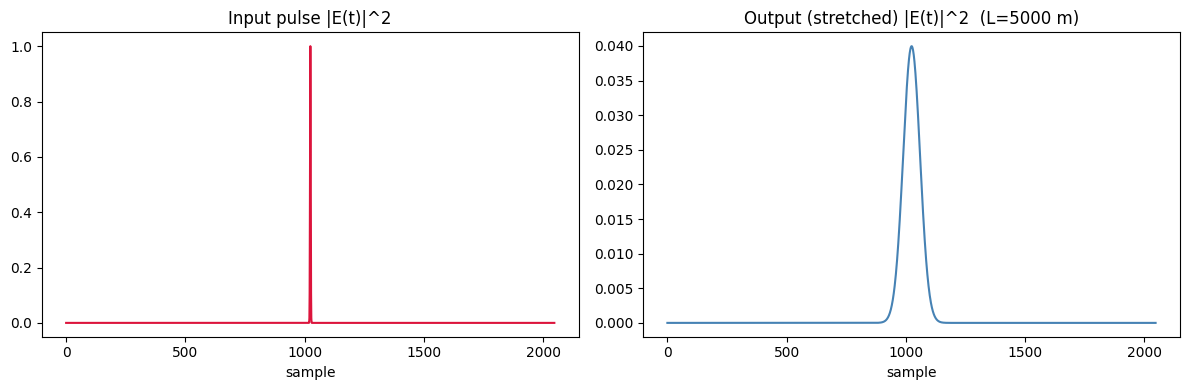

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(np.abs(pulse_np)**2, color='crimson')
axes[0].set_title('Input pulse |E(t)|^2')
axes[0].set_xlabel('sample')
axes[1].plot(res_torch['I_out'].numpy(), color='steelblue')
axes[1].set_title(f'Output (stretched) |E(t)|^2  (L={L:.0f} m)')
axes[1].set_xlabel('sample')
plt.tight_layout()
plt.savefig('tsdft_torch_stretch.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Plots: Stretch Factor vs. Fiber Length (Differentiable Curve)

`achieved_stretch_factor` computes the output/input RMS-width ratio
end-to-end through the FFT-based propagation -- fully differentiable with
respect to `L_m`, which is exactly what section 6's gradient-based design
needs.


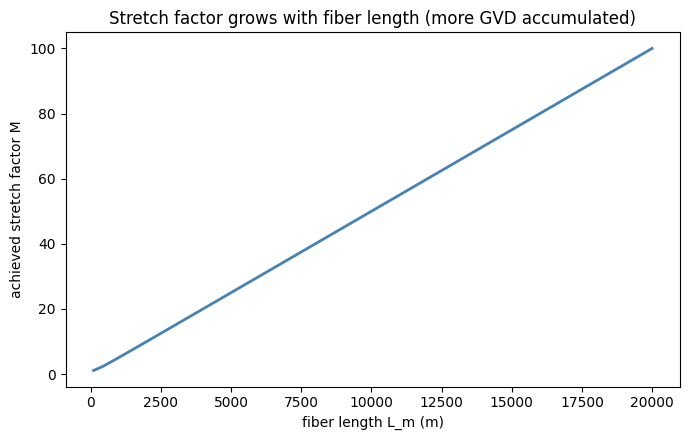

In [4]:
t_full = (torch.arange(N, dtype=torch.float64) - N//2) * dt
E_in_t = torch.exp(-t_full**2/(2*T0**2)).to(torch.complex128)

L_sweep = torch.linspace(100.0, 20000.0, 60, dtype=torch.float64)
M_sweep = [float(dft_torch.achieved_stretch_factor(E_in_t, float(Lv), beta2, dt, t_full))
           for Lv in L_sweep]

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(L_sweep.numpy(), M_sweep, color='steelblue', lw=2)
ax.set_xlabel('fiber length L_m (m)'); ax.set_ylabel('achieved stretch factor M')
ax.set_title('Stretch factor grows with fiber length (more GVD accumulated)')
plt.tight_layout()
plt.savefig('tsdft_torch_stretch_vs_length.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. SymPy Cross-Check: the Closed-Form Answer This Design Problem Has

For a Gaussian pulse specifically, $M=L/L_D$, $L_D=T_0^2/|\beta_2|$ is
EXACT -- giving a ground truth to check the gradient-based method against
in section 6, before trusting it on a pulse shape where no closed form
exists.


In [5]:
import sympy as sp
T0_s, beta2_s, L_s, M_s = sp.symbols('T_0 beta_2 L M', positive=True)
L_D_expr = T0_s**2/beta2_s
M_expr = L_s/L_D_expr
L_from_M = sp.solve(sp.Eq(M_s, M_expr), L_s)[0]
print("L(M) =", L_from_M)


L(M) = M*T_0**2/beta_2


## 6. Gradient-Based Fiber-Length Design (What Torch Adds Beyond NumPy)

Instead of solving `L(M)` symbolically (only possible because the pulse is
exactly Gaussian), find `L_m` by gradient descent on the ACTUAL simulated
stretch factor -- a procedure that works identically for any pulse shape,
including ones with no closed form. Checked here against the closed-form
answer specifically so the method is trustworthy before relying on it
where no closed form exists.


Target stretch factor: 30.0
Closed-form L_m:        6000.0 m
Autograd-found L_m:      5996.7 m
Relative error:          0.056%


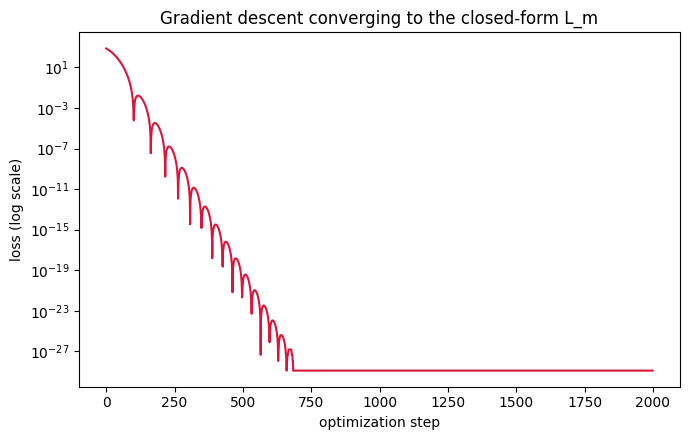

In [6]:
target_M = 30.0
result = dft_torch.design_fiber_length_for_stretch_factor(
    T0_s=T0, dt_s=dt, beta2=beta2, target_stretch_factor=target_M,
    n_pts=N, n_iter=2000, lr=100.0)

print(f"Target stretch factor: {target_M}")
print(f"Closed-form L_m:        {result['L_m_closed_form']:.1f} m")
print(f"Autograd-found L_m:      {result['L_m_found']:.1f} m")
print(f"Relative error:          {result['relative_error']*100:.3f}%")

fig, ax = plt.subplots(figsize=(7,4.5))
ax.semilogy(result['loss_history'], color='crimson')
ax.set_xlabel('optimization step'); ax.set_ylabel('loss (log scale)')
ax.set_title('Gradient descent converging to the closed-form L_m')
plt.tight_layout()
plt.savefig('tsdft_torch_design_convergence.png', dpi=100, bbox_inches='tight')
plt.show()


## 7. Engineering Interpretation

- Section 2's machine-precision match matters for the same reason
  `dgs/gs_torch.py` bothers to exist alongside `dgs/gs_core.py`: once a
  GPU port is VERIFIED faithful, every downstream torch-specific
  capability (batching, autograd, GPU throughput) inherits that trust
  instead of needing separate validation from scratch.
- Section 6's gradient-based design is the real payoff: for a REAL
  measured pulse shape (not a textbook Gaussian), there usually is no
  closed form for "what fiber length gives me stretch factor M" -- but
  the identical gradient-descent procedure still works, because it only
  needs the forward simulation to be differentiable, not analytically
  invertible.


## 8. Research Discussion

- Could `design_fiber_length_for_stretch_factor` be extended to jointly
  optimize BOTH `beta2` (fiber choice) and `L_m` (length) for a target
  stretch factor AND a target far-field correlation (matching
  `dgs/dispersive_fourier.py`'s `far_field_ok`/`ff_correlation`
  diagnostics), a genuinely 2-parameter design problem autograd handles
  naturally?
- This notebook's gradient-based design targets a SCALAR (stretch
  factor). Could the same machinery instead target a full desired output
  intensity PROFILE (e.g. "make the stretched pulse look like this
  target waveform"), turning fiber design into an inverse-problem
  optimization akin to `dgs/gs_diff.py`'s differentiable GS approach?


## 9. Possible Experiments

1. Replace the Gaussian pulse with a real measured pulse shape (no closed
   form for L(M)) and confirm `design_fiber_length_for_stretch_factor`
   still converges to a sensible answer, checked only against the
   simulated forward model (no ground truth available in that case).
2. Extend section 6 to optimize `beta2` jointly with `L_m` for a 2-fiber
   dispersion-compensated system.
3. Port `dgs/dispersive_fourier.py`'s `kramers_kronig_n` causality check
   to torch as well, and compare its accuracy against the numpy version's
   already-known limitations (see `dgs/connective_tissue_electrodynamics.py`'s
   module docstring, which found the existing kramers_kronig_n
   numerically inaccurate for a plain Debye test case).


## 10. Future Improvements

- If real GPU throughput matters for a specific downstream use (batch
  processing many pulses at once, matching `dgs/gs_torch.py`'s batched
  GS), extend `gvd_propagate_torch` to accept a batched `E_in` (shape
  `(B, N)`) rather than one pulse at a time.
- Benchmark actual GPU vs. CPU speedup for this specific FFT-based
  operation before claiming one, following this session's own precedent
  (`dgs/maxwell_discrete_symmetries_torch.py`'s honest finding that a
  simple elementwise op saw negligible GPU benefit -- FFT-heavy code like
  this module is a better GPU candidate, but should be measured, not assumed).
